Title: Capacity_data_scenarios.ipynb

Purpose: Create capacity data maps for different scenarios

Author: Onno Nennecke on 17.12.2025 Modified: 06.01.2026

Input data: 

- Capacity data Nettoleistung
    - This file lies here: '/climca/people/onennecke/Wind_Solar_MaStR/processed_data/'

Output data:

- Capacity data Nettoleistung for different scenarios
    - This file lies here: '/climca/people/onennecke/Wind_Solar_MaStR/processed_data/'


In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


In [2]:
def setup_gridlines(ax, lon_edges, lat_edges, deg=2, alpha=0, ll=True):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    # make sure ticks line up with gridlines:
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=10)
    
def setup_gridlines_small(ax, lon_edges, lat_edges, deg = 2, alpha = 0.4, ll = True, bl = True, label_size = 16):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    # ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=18)

In [3]:
# Read in exisiting capacity data
solar_ic = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')
wind_onshore_ic = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
wind_offshore_ic = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')


In [4]:
Solar_IC_2024_sum = solar_ic['solar_cap'].sum().values
print('Solar 2024 IC: ', Solar_IC_2024_sum)
Wind_Onshore_IC_2024_sum = wind_onshore_ic['wind_on_cap'].sum().values
print('Wind Onshore 2024 IC: ', Wind_Onshore_IC_2024_sum)
Wind_Offshore_IC_2024_sum = wind_offshore_ic['wind_off_cap'].sum().values
print('Wind Offshore 2024 IC: ', Wind_Offshore_IC_2024_sum)

Solar 2024 IC:  88379261.58999999
Wind Onshore 2024 IC:  63410807.01699999
Wind Offshore 2024 IC:  9215093.0


In [5]:
print(solar_ic['solar_cap'].size)
print(wind_onshore_ic['wind_on_cap'].size)
print(wind_offshore_ic['wind_off_cap'].size)

90
90
90


In [6]:
mask_solar = xr.where(np.isfinite(solar_ic['solar_cap']), 1, 0)
mask_solar.sum()

print(np.isfinite(solar_ic['solar_cap']).sum().values)
print(np.isfinite(wind_onshore_ic['wind_on_cap']).sum().values)
print(np.isfinite(wind_offshore_ic['wind_off_cap']).sum().values)

66
63
9


In [7]:
def capacity_scenario(current_IC, scenario_sum, method = 'proportional'):
    current_IC_sum = current_IC.sum().values
    num_used_cells = np.isfinite(current_IC).sum().values
    if method == 'proportional':
        factor = scenario_sum / current_IC_sum
        scenario_IC = current_IC * factor
        return scenario_IC
    elif method == 'uniform_increase':
        increase = (scenario_sum - current_IC_sum) / num_used_cells
        scenario_IC = current_IC + increase
        return scenario_IC
    elif method == 'uniform_capacity':
        mask = xr.where(np.isfinite(current_IC), 1, 0)
        uniform_capacity = scenario_sum / num_used_cells
        scenario_IC = xr.full_like(current_IC, uniform_capacity) * mask
        scenario_IC = xr.where(scenario_IC == 0, np.nan, scenario_IC) # replace 0 with nan
        return scenario_IC

In [8]:
cap_future = pd.read_csv('/home/onennecke/Capacity_data/cap_ger_2030-2045-2050_v3.csv', 
                           sep=',', header=1, index_col=0)
# show selected columns
capacity_data_max = cap_future.iloc[list(range(4, 5))+ list(range(7, 8))  + list(range(14, 18)), :]
capacity_data_max

,---,"EEG, Wind-See-Gesetz","EEG, Wind-See-Gesetz.1","EEG, Wind-See-Gesetz.2",Ariadne 2025 (scenario: Technologiemix),Ariadne 2025 (scenario: Technologiemix).1,Ariadne 2025 (scenario: Technologiemix).2,---.1,"EEG, Wind-See-Gesetz.3","EEG, Wind-See-Gesetz.4",...,Ariadne 2025 (scenario: Technologiemix).3,Ariadne 2025 (scenario: Technologiemix).4,Ariadne 2025 (scenario: Technologiemix).5,---.2,"EEG, Wind-See-Gesetz.6","EEG, Wind-See-Gesetz.7","EEG, Wind-See-Gesetz.8",Ariadne 2025 (scenario: Technologiemix).6,Ariadne 2025 (scenario: Technologiemix).7,Ariadne 2025 (scenario: Technologiemix).8
source,,,,,,,,,,,,,,,,,,,,,
max,47 848.96,115.00,30.00,215.00,113.47,29.30,235.00,51 500.96,160.00,55.00,...,157.21,65.00,464.65,55 153.96,166.00,80.00,400.00,162.79,63.86,471.62
+aux1,NaN,cap_wion_ger,cap_wioff_ger,cap_pv_ger,cap_wion_ger,cap_wioff_ger,cap_pv_ger,NaN,cap_wion_ger,cap_wioff_ger,...,cap_wion_ger,cap_wioff_ger,cap_pv_ger,NaN,cap_wion_ger,cap_wioff_ger,cap_pv_ger,cap_wion_ger,cap_wioff_ger,cap_pv_ger
year,2030,2030,2030,2030,2030,2030,2030,2040,2040,2040,...,2040,2040,2040,2050,2050,2050,2050,2050,2050,2050
scenario,---,policy,policy,policy,decarb,decarb,decarb,---,policy,policy,...,decarb,decarb,decarb,---,policy,policy,policy,decarb,decarb,decarb
unit,dd.mm.yy hh:mm,GW_el,GW_el,GW_el,GW_el,GW_el,GW_el,dd.mm.yy hh:mm,GW_el,GW_el,...,GW_el,GW_el,GW_el,dd.mm.yy hh:mm,GW_el,GW_el,GW_el,GW_el,GW_el,GW_el
NAME,time2030,cap_wion_ger2030-policy,cap_wioff_ger2030-policy,cap_pv_ger2030-policy,cap_wion_ger2030-decarb,cap_wioff_ger2030-decarb,cap_pv_ger2030-decarb,time2040,cap_wion_ger2040-policy,cap_wioff_ger2040-policy,...,cap_wion_ger2040-decarb,cap_wioff_ger2040-decarb,cap_pv_ger2040-decarb,time2050,cap_wion_ger2050-policy,cap_wioff_ger2050-policy,cap_pv_ger2050-policy,cap_wion_ger2050-decarb,cap_wioff_ger2050-decarb,cap_pv_ger2050-decarb


In [9]:
scenario = 'policy'
year = '2040'

In [10]:
wi_on_capacity = float(capacity_data_max.loc['max', ((capacity_data_max.loc['scenario'] == scenario) &(capacity_data_max.loc['year'] == year) &(capacity_data_max.loc['+aux1'] == 'cap_wion_ger'))].iloc[0])
wi_off_capacity = float(capacity_data_max.loc['max', ((capacity_data_max.loc['scenario'] == scenario) &(capacity_data_max.loc['year'] == year) &(capacity_data_max.loc['+aux1'] == 'cap_wioff_ger'))].iloc[0])
pv_capacity = float(capacity_data_max.loc['max', ((capacity_data_max.loc['scenario'] == scenario) &(capacity_data_max.loc['year'] == year) &(capacity_data_max.loc['+aux1'] == 'cap_pv_ger'))].iloc[0])

In [11]:
solar_IC_2040_c_prop = capacity_scenario(solar_ic['solar_cap'], pv_capacity*1000000, method='proportional')
solar_IC_2040_c_uni_incr = capacity_scenario(solar_ic['solar_cap'], pv_capacity*1000000, method='uniform_increase')
solar_IC_2040_c_uni_cap = capacity_scenario(solar_ic['solar_cap'], pv_capacity*1000000, method='uniform_capacity')

wind_on_IC_2040_c_prop = capacity_scenario(wind_onshore_ic['wind_on_cap'], wi_on_capacity*1000000, method='proportional')
wind_on_IC_2040_c_uni_incr = capacity_scenario(wind_onshore_ic['wind_on_cap'], wi_on_capacity*1000000, method='uniform_increase')
wind_on_IC_2040_c_uni_cap = capacity_scenario(wind_onshore_ic['wind_on_cap'], wi_on_capacity*1000000, method='uniform_capacity')

wind_off_IC_2040_c_prop = capacity_scenario(wind_offshore_ic['wind_off_cap'], wi_off_capacity*1000000, method='proportional')
wind_off_IC_2040_c_uni_incr = capacity_scenario(wind_offshore_ic['wind_off_cap'], wi_off_capacity*1000000, method='uniform_increase')
wind_off_IC_2040_c_uni_cap = capacity_scenario(wind_offshore_ic['wind_off_cap'], wi_off_capacity*1000000, method='uniform_capacity')

In [12]:
# Write the new capacity data back to the datasets and then to netcdf files
solar_ic_2040 = solar_ic.copy()
wind_onshore_ic_2040 = wind_onshore_ic.copy()
wind_offshore_ic_2040 = wind_offshore_ic.copy()


solar_ic_2040['solar_cap'] = solar_IC_2040_c_prop

wind_onshore_ic_2040['wind_on_cap'] = wind_on_IC_2040_c_prop

wind_offshore_ic_2040['wind_off_cap'] = wind_off_IC_2040_c_prop

solar_ic_2040.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_2040_policy_proportional.nc')
wind_onshore_ic_2040.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic_2040_policy_proportional.nc')
wind_offshore_ic_2040.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_2040_policy_proportional.nc')

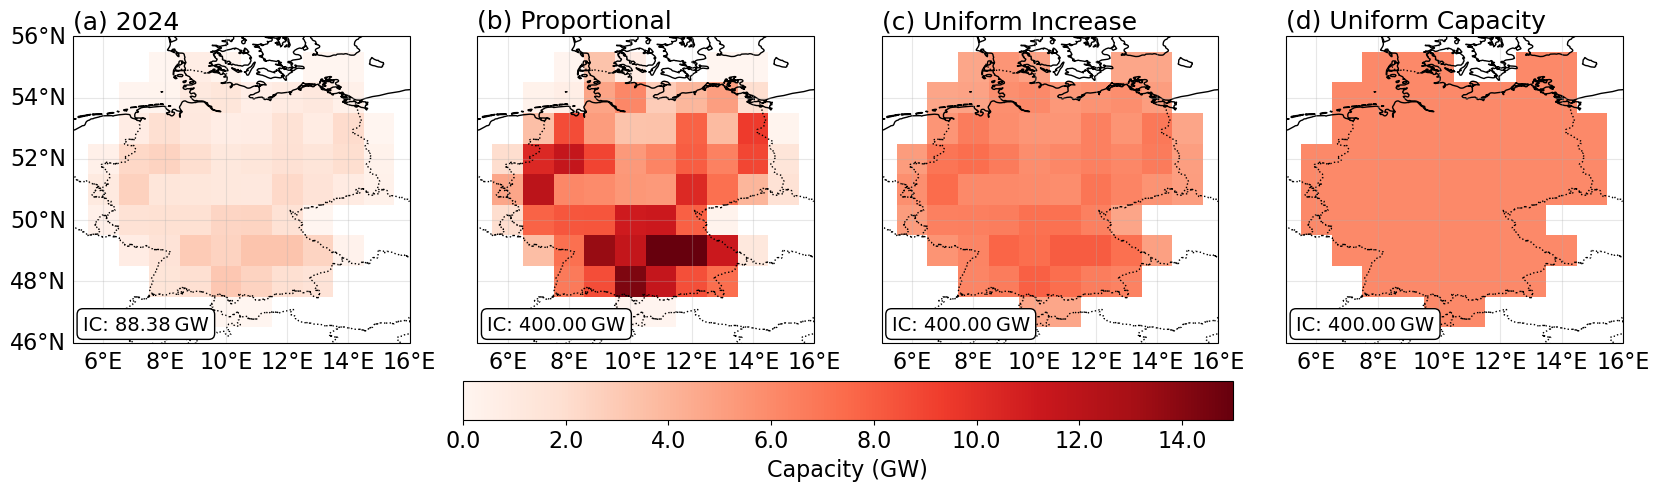

In [13]:
# Make a plot to compare the different methods

lon_edges = solar_ic.lon.values
lat_edges = solar_ic.lat.values
# lat_edges = np.insert(lat_edges, 0, 46)


# Convert to MW
xxx1 = solar_ic['solar_cap'] / 1000000
xxx2 = solar_IC_2040_c_prop / 1000000
xxx3 = solar_IC_2040_c_uni_incr / 1000000
xxx4 = solar_IC_2040_c_uni_cap / 1000000


# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max(), xxx3.max(), xxx4.max())


mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

lon_min, lon_max = lon_edges.min(), lon_edges.max()
lat_min, lat_max = lat_edges.min(), lat_edges.max()

fig, axes = plt.subplots(
    1, 4, figsize=(20, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'hspace': 0.003} 
)

axes = axes.flatten()

# axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]
data = [xxx1, xxx2, xxx3, xxx4]
labels = ['(a) 2024', '(b) Proportional', '(c) Uniform Increase', '(d) Uniform Capacity']
capacities = [
    f"IC: {solar_ic['solar_cap'].sum() / 1000000:.2f} GW",
    f"IC: {solar_IC_2040_c_prop.sum() / 1000000:.2f} GW",
    f"IC: {solar_IC_2040_c_uni_incr.sum() / 1000000:.2f} GW",
    f"IC: {solar_IC_2040_c_uni_cap.sum() / 1000000:.2f} GW",
]
label_sizes = {'title': 18, 'box': 14}

for ax, dat, lab, cap, ll, bl in zip(axes, data, labels, capacities, [True, False, False, False], [True, True, True, True]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )
    
    ax.set_extent([lon_min-1, lon_max+1.001, lat_min - 1.001, lat_max+1.001], crs=ccrs.PlateCarree())

    setup_gridlines_small(ax, lon_edges=lon_edges, lat_edges=lat_edges, deg=2, alpha=0.3, ll=ll, bl=bl)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed capacity text in lower right (axes coords)
    ax.text(
        0.03, 0.03, cap,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.05        # space between panels and colorbar
)
cbar.set_label('Capacity (GW)')
cbar.ax.tick_params()
# Explicit ticks from 0.0 to 4.0 every 0.5
# ticks = np.arange(0.0, 4.0 + 0.5, 0.5)   # array([0. , 0.5, 1. , ..., 4. ])
# cbar.set_ticks(ticks)

# Force one decimal place on tick labels
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# plt.tight_layout()
# save the plot
# plt.savefig('/home/onennecke/Code/Figures/Installed_capacity.png', dpi=600, bbox_inches='tight')
plt.show()


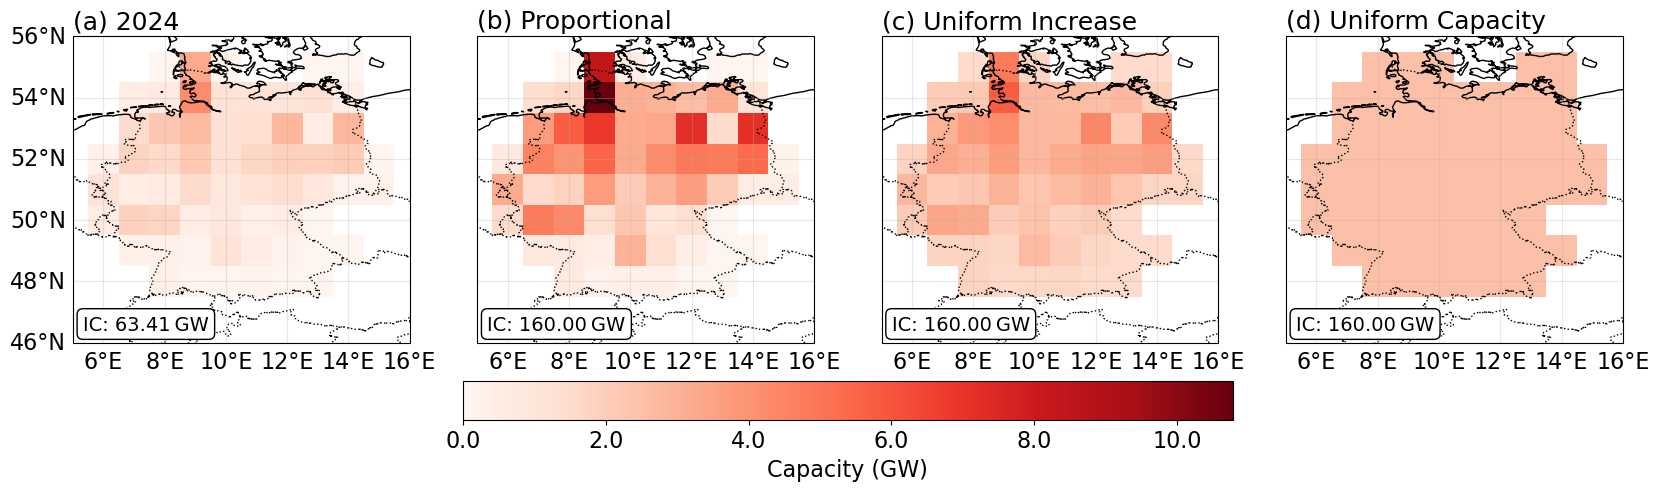

In [50]:
# Make a plot to compare the different methods

lon_edges = wind_onshore_ic.lon.values
lat_edges = wind_onshore_ic.lat.values
# lat_edges = np.insert(lat_edges, 0, 46)


# Convert to MW
xxx1 = wind_onshore_ic['wind_on_cap'] / 1000000
xxx2 = wind_on_IC_2040_c_prop / 1000000
xxx3 = wind_on_IC_2040_c_uni_incr / 1000000
xxx4 = wind_on_IC_2040_c_uni_cap / 1000000

# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max(), xxx3.max(), xxx4.max())


mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

lon_min, lon_max = lon_edges.min(), lon_edges.max()
lat_min, lat_max = lat_edges.min(), lat_edges.max()

fig, axes = plt.subplots(
    1, 4, figsize=(20, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'hspace': 0.003} 
)

axes = axes.flatten()

# axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]
data = [xxx1, xxx2, xxx3, xxx4]
labels = ['(a) 2024', '(b) Proportional', '(c) Uniform Increase', '(d) Uniform Capacity']
capacities = [
    f"IC: {wind_onshore_ic['wind_on_cap'].sum() / 1000000:.2f} GW",
    f"IC: {wind_on_IC_2040_c_prop.sum() / 1000000:.2f} GW",
    f"IC: {wind_on_IC_2040_c_uni_incr.sum() / 1000000:.2f} GW",
    f"IC: {wind_on_IC_2040_c_uni_cap.sum() / 1000000:.2f} GW",
]
label_sizes = {'title': 18, 'box': 14}

for ax, dat, lab, cap, ll, bl in zip(axes, data, labels, capacities, [True, False, False, False], [True, True, True, True]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )
    
    ax.set_extent([lon_min-1, lon_max+1.001, lat_min - 1.001, lat_max+1.001], crs=ccrs.PlateCarree())

    setup_gridlines_small(ax, lon_edges=lon_edges, lat_edges=lat_edges, deg=2, alpha=0.3, ll=ll, bl=bl)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed capacity text in lower right (axes coords)
    ax.text(
        0.03, 0.03, cap,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.05        # space between panels and colorbar
)
cbar.set_label('Capacity (GW)')
cbar.ax.tick_params()
# Explicit ticks from 0.0 to 4.0 every 0.5
# ticks = np.arange(0.0, 4.0 + 0.5, 0.5)   # array([0. , 0.5, 1. , ..., 4. ])
# cbar.set_ticks(ticks)

# Force one decimal place on tick labels
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# plt.tight_layout()
# save the plot
# plt.savefig('/home/onennecke/Code/Figures/Installed_capacity.png', dpi=600, bbox_inches='tight')
plt.show()


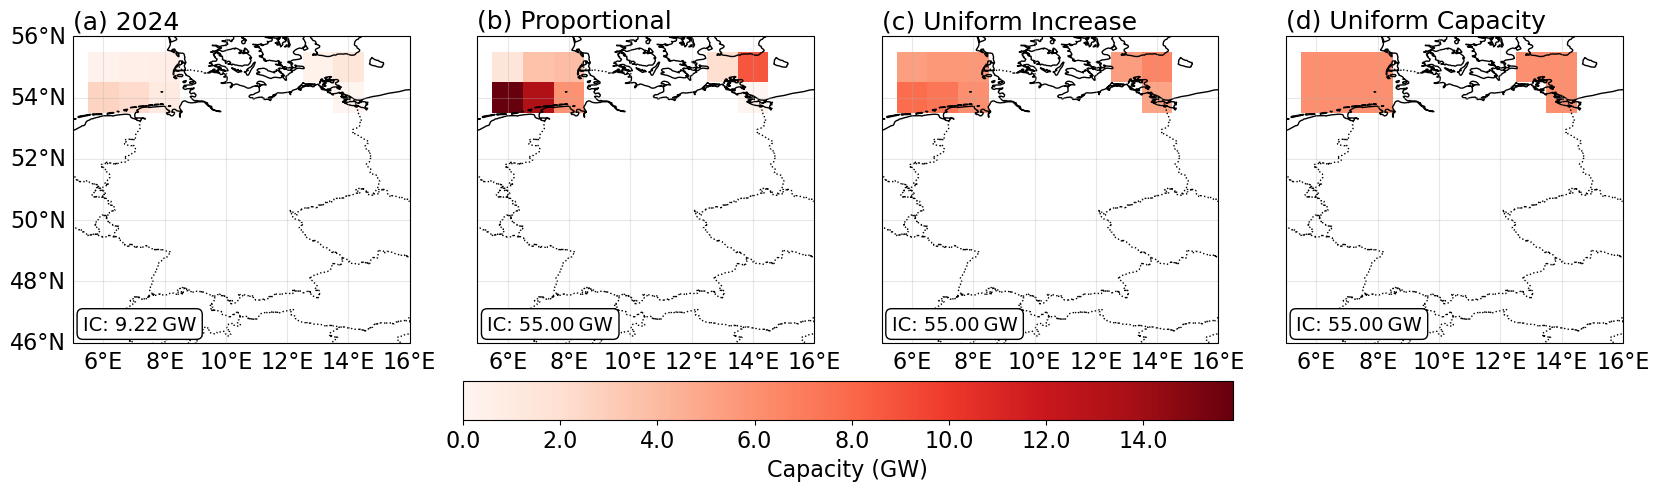

In [51]:
# Make a plot to compare the different methods

lon_edges = wind_offshore_ic.lon.values
lat_edges = wind_offshore_ic.lat.values
# lat_edges = np.insert(lat_edges, 0, 46)


# Convert to MW
xxx1 = wind_offshore_ic['wind_off_cap'] / 1000000
xxx2 = wind_off_IC_2040_c_prop / 1000000
xxx3 = wind_off_IC_2040_c_uni_incr / 1000000
xxx4 = wind_off_IC_2040_c_uni_cap / 1000000

# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max(), xxx3.max(), xxx4.max())


mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

lon_min, lon_max = lon_edges.min(), lon_edges.max()
lat_min, lat_max = lat_edges.min(), lat_edges.max()

fig, axes = plt.subplots(
    1, 4, figsize=(20, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'hspace': 0.003} 
)

axes = axes.flatten()

# axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]
data = [xxx1, xxx2, xxx3, xxx4]
labels = ['(a) 2024', '(b) Proportional', '(c) Uniform Increase', '(d) Uniform Capacity']
capacities = [
    f"IC: {wind_offshore_ic['wind_off_cap'].sum() / 1000000:.2f} GW",
    f"IC: {wind_off_IC_2040_c_prop.sum() / 1000000:.2f} GW",
    f"IC: {wind_off_IC_2040_c_uni_incr.sum() / 1000000:.2f} GW",
    f"IC: {wind_off_IC_2040_c_uni_cap.sum() / 1000000:.2f} GW",
]
label_sizes = {'title': 18, 'box': 14}

for ax, dat, lab, cap, ll, bl in zip(axes, data, labels, capacities, [True, False, False, False], [True, True, True, True]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )
    
    ax.set_extent([lon_min-1, lon_max+1.001, lat_min - 1.001, lat_max+1.001], crs=ccrs.PlateCarree())

    setup_gridlines_small(ax, lon_edges=lon_edges, lat_edges=lat_edges, deg=2, alpha=0.3, ll=ll, bl=bl)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed capacity text in lower right (axes coords)
    ax.text(
        0.03, 0.03, cap,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.05        # space between panels and colorbar
)
cbar.set_label('Capacity (GW)')
cbar.ax.tick_params()
# Explicit ticks from 0.0 to 4.0 every 0.5
# ticks = np.arange(0.0, 4.0 + 0.5, 0.5)   # array([0. , 0.5, 1. , ..., 4. ])
# cbar.set_ticks(ticks)

# Force one decimal place on tick labels
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# plt.tight_layout()
# save the plot
# plt.savefig('/home/onennecke/Code/Figures/Installed_capacity.png', dpi=600, bbox_inches='tight')
plt.show()


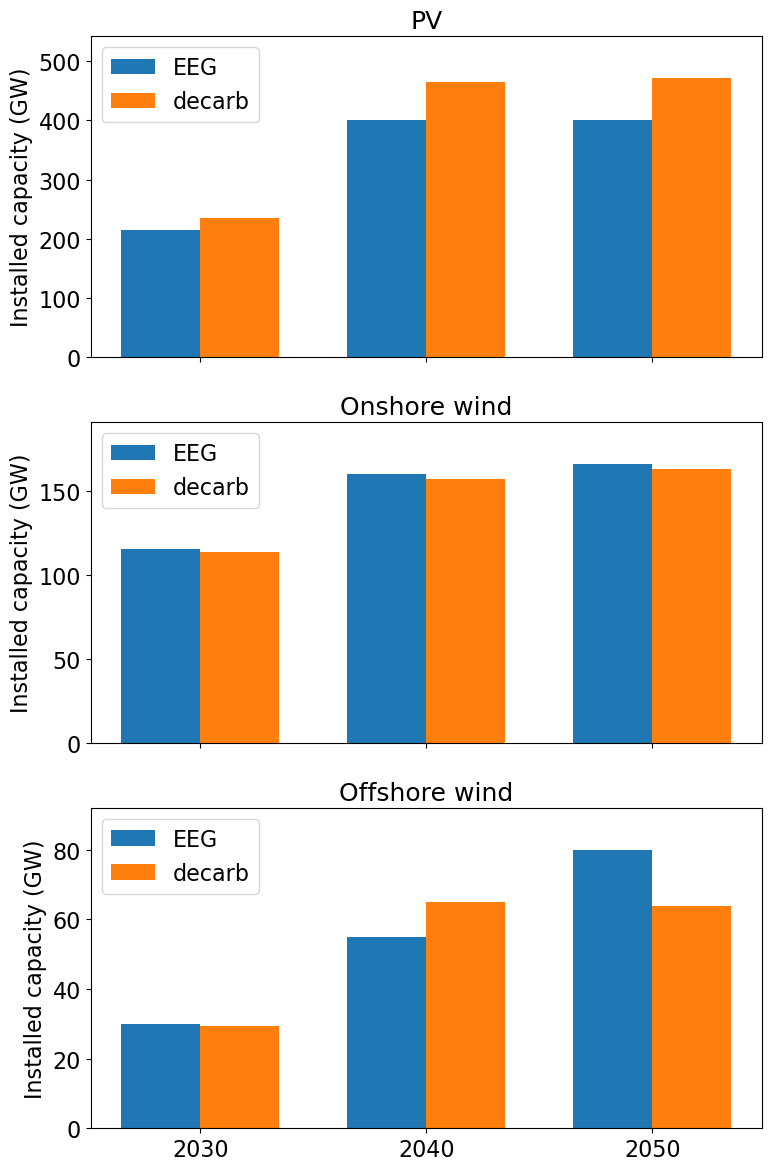

In [ ]:

# --- configuration ---
years = [2030, 2040, 2050]
sources = {
    "EEG": "policy",
    "Decarb": "decarb"
}
techs = {
    "PV": "pv",
    "Onshore wind": "wion",
    "Offshore wind": "wioff"
}

# extract column names and data row (as you had)
names = capacity_data_max.iloc[-1]
values = capacity_data_max.iloc[1]

# --- plotting ---
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

x = np.arange(len(years))
width = 0.35

for ax, (tech_name, tech_key) in zip(axes, techs.items()):
    # collect all plotted values for this subplot so we can compute the top properly
    all_vals = []

    for i, (source_name, source_key) in enumerate(sources.items()):
        vals = [
            values[
                names.str.contains(f"cap_{tech_key}_ger{year}-{source_key}")
            ].values[0]
            for year in years
        ]
        vals = np.array(vals, dtype=float)  # ensure numeric
        all_vals.append(vals)

        ax.bar(
            x + (i - 0.5) * width,
            vals,
            width,
            label=source_name
        )

    # compute top from actual data (ignore NaNs); ensure a sensible minimum top
    if len(all_vals) > 0:
        concat = np.concatenate(all_vals)
        # ignore NaNs
        if np.all(np.isnan(concat)):
            top = 1.0
        else:
            top = np.nanmax(concat)
            if top <= 0:
                top = 1.0
    else:
        top = 1.0

    # FORCE y-axis to start at 0, auto top with headroom
    ax.set_ylim(0, top * 1.15)

    ax.set_title(tech_name)
    ax.set_ylabel("Installed capacity (GW)")
    ax.legend()

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(years)

plt.tight_layout()
plt.show()


In [12]:
# Scenarios
# 2037
Solar_IC_2037_a_sum = 280
Solar_IC_2037_b_sum = 345
Solar_IC_2037_c_sum = 380

Wind_Onshore_IC_2037_a_sum = 105
Wind_Onshore_IC_2037_b_sum = 159
Wind_Onshore_IC_2037_c_sum = 159

Wind_Offshore_IC_2037_a_sum = 54.4
Wind_Offshore_IC_2037_b_sum = 60.4
Wind_Offshore_IC_2037_c_sum = 60.4

# 2045
Solar_IC_2045_a_sum = 330
Solar_IC_2045_b_sum = 400
Solar_IC_2045_c_sum = 500

Wind_Onshore_IC_2045_a_sum = 125
Wind_Onshore_IC_2045_b_sum = 160
Wind_Onshore_IC_2045_c_sum = 180

Wind_Offshore_IC_2045_a_sum = 65.2
Wind_Offshore_IC_2045_b_sum = 75.5
Wind_Offshore_IC_2045_c_sum = 81.5

In [13]:
# Factors to convert existing capacities to scenario capacities
factor_Solar_2037_a = Solar_IC_2037_a_sum / Solar_IC_2024_sum
factor_Solar_2037_b = Solar_IC_2037_b_sum / Solar_IC_2024_sum
factor_Solar_2037_c = Solar_IC_2037_c_sum / Solar_IC_2024_sum

factor_Wind_Onshore_2037_a = Wind_Onshore_IC_2037_a_sum / Wind_Onshore_IC_2024_sum
factor_Wind_Onshore_2037_b = Wind_Onshore_IC_2037_b_sum / Wind_Onshore_IC_2024_sum
factor_Wind_Onshore_2037_c = Wind_Onshore_IC_2037_c_sum / Wind_Onshore_IC_2024_sum

factor_Wind_Offshore_2037_a = Wind_Offshore_IC_2037_a_sum / Wind_Offshore_IC_2024_sum
factor_Wind_Offshore_2037_b = Wind_Offshore_IC_2037_b_sum / Wind_Offshore_IC_2024_sum
factor_Wind_Offshore_2037_c = Wind_Offshore_IC_2037_c_sum / Wind_Offshore_IC_2024_sum

factor_Solar_2045_a = Solar_IC_2045_a_sum / Solar_IC_2024_sum
factor_Solar_2045_b = Solar_IC_2045_b_sum / Solar_IC_2024_sum
factor_Solar_2045_c = Solar_IC_2045_c_sum / Solar_IC_2024_sum

factor_Wind_Onshore_2045_a = Wind_Onshore_IC_2045_a_sum / Wind_Onshore_IC_2024_sum
factor_Wind_Onshore_2045_b = Wind_Onshore_IC_2045_b_sum / Wind_Onshore_IC_2024_sum
factor_Wind_Onshore_2045_c = Wind_Onshore_IC_2045_c_sum / Wind_Onshore_IC_2024_sum

factor_Wind_Offshore_2045_a = Wind_Offshore_IC_2045_a_sum / Wind_Offshore_IC_2024_sum
factor_Wind_Offshore_2045_b = Wind_Offshore_IC_2045_b_sum / Wind_Offshore_IC_2024_sum
factor_Wind_Offshore_2045_c = Wind_Offshore_IC_2045_c_sum / Wind_Offshore_IC_2024_sum

In [14]:
solar_ic_2037_a = solar_ic['solar_cap'] * factor_Solar_2037_a
solar_ic_2037_a

<xarray.DataArray 'solar_cap' (lat: 9, lon: 10)> Size: 720B
array([[        nan,         nan,         nan,         nan,  0.06247939,
         0.05174249,         nan,         nan,         nan,         nan],
       [        nan,         nan,  4.74126874,  6.03876996,  9.97258011,
         8.07564534,  5.99038193,  5.08538734,         nan,         nan],
       [        nan,  2.51275797,  5.07087144,  9.44164868,  8.11569771,
        10.4916488 , 10.46812621,  7.8876147 ,  0.84405882,         nan],
       [ 1.4281372 ,  5.44873449,  5.7934701 ,  5.85463232,  7.78633051,
         7.83734393,  5.5122744 ,  0.13093222,         nan,         nan],
       [ 3.31721574,  8.43833757,  4.27823168,  4.16347307,  3.80721869,
         3.69349628,  7.21564912,  5.07084236,  2.79577171,  1.19175059],
       [ 1.3949554 ,  7.26680527,  8.07945038,  6.2938785 ,  3.71505073,
         4.40528505,  5.60758506,  4.47736393,  6.25040646,  1.02225864],
       [        nan,  2.47463293,  6.09219042,  3.64127864,  2.36626996,
         2.41278788,  5.47552918,  2.65204815,  6.57051871,  0.09774496],
       [        nan,  0.21936619,  0.48816926,  3.36238069,  4.29739405,
         2.03804583,  2.78675491,  3.55783829,  1.36085956,         nan],
       [        nan,         nan,  0.05387877,  2.33676487,  0.53448951,
                nan,         nan,  0.01926888,  0.03422732,         nan]])
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs       int64 8B ...
    gridtype  <U6 24B ...